图片已保存为: three_stage_performance_combined.svg 和 three_stage_performance_combined.pdf


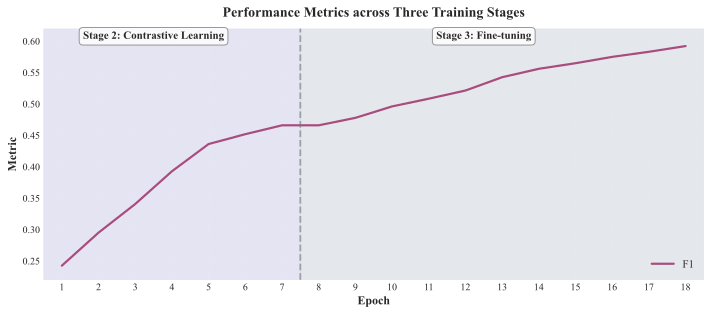

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 设置matplotlib样式
plt.style.use('seaborn-v0_8-darkgrid')  # 使用seaborn风格
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['font.family'] = 'Times New Roman'  # 设置字体为Times New Roman


%config InlineBackend.figure_format = 'svg'


# ============ 数据准备 ============
# 阶段epoch数
stage1_epochs = 7
stage2_epochs = 11

# 数据（F1）
stage1_f1 = [0.2425, 0.2951, 0.3407, 0.3928, 0.4362, 0.4519, 0.4660]
stage2_f1 = [0.4660, 0.4779, 0.4961, 0.5084, 0.5214, 0.5426, 0.5560, 0.5649, 0.5750, 0.5831, 0.5922]

# 横坐标
stage1_x = np.arange(1, stage1_epochs + 1)
stage2_x = np.arange(stage1_epochs + 1, stage1_epochs + stage2_epochs + 1)

# 拼接连续坐标和数据
x_all = np.concatenate([stage1_x, stage2_x])
f1_all = np.concatenate([stage1_f1, stage2_f1])


# ============ 绘图 ============
fig, ax = plt.subplots(figsize=(10, 4.5))

color_f1 = '#A23B72'  # 紫红色系 - F1

# 连续绘制F1曲线，无标记
ax.plot(x_all, f1_all, color=color_f1, linewidth=2.2, label='F1', alpha=0.9)

# 阶段分割线和背景色
ax.axvline(x=stage1_epochs + 0.5, color='#6C757D', linestyle='--', linewidth=1.8, alpha=0.6)
ax.axvspan(0.5, stage1_epochs + 0.5, alpha=0.03, color='blue')
ax.axvspan(stage1_epochs + 0.5, stage1_epochs + stage2_epochs + 0.5, alpha=0.03, color='green')

# 阶段标注
ax.text(stage1_epochs / 2, 0.60, 'Stage 2: Contrastive Learning', 
        ha='center', va='bottom', fontsize=11, fontweight='bold', 
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='gray', alpha=0.8))
ax.text(stage1_epochs + stage2_epochs / 2, 0.60, 'Stage 3: Fine-tuning', 
        ha='center', va='bottom', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='gray', alpha=0.8))

# 坐标轴设置
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Metric', fontsize=12, fontweight='bold')
ax.set_ylim(0.22, 0.62)
ax.set_xlim(0.5, stage1_epochs + stage2_epochs + 0.5)

# x轴刻度
xticks = list(range(1, stage1_epochs + stage2_epochs + 1))
xtick_labels = [str(i) for i in xticks]
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)

ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.8)
ax.legend(loc='lower right', fontsize=11, framealpha=0.95, shadow=True)

# 标题
ax.set_title('Performance Metrics across Three Training Stages', 
             fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()

plt.savefig('three_stage_performance_combined.svg', dpi=300, bbox_inches='tight')
plt.savefig('three_stage_performance_combined.pdf', bbox_inches='tight', format='pdf')

print("图片已保存为: three_stage_performance_combined.svg 和 three_stage_performance_combined.pdf")

plt.show()


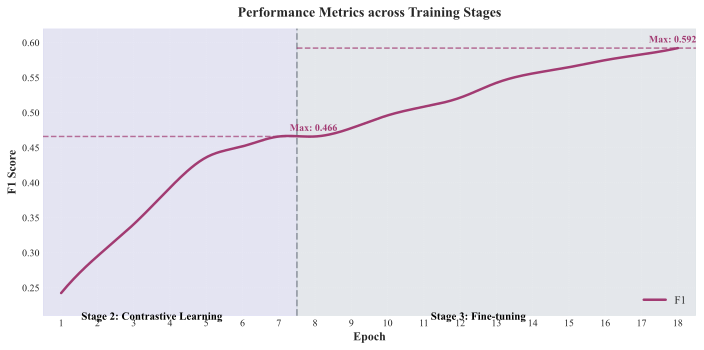

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# 设置matplotlib样式
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['font.family'] = 'Times New Roman'

# ============ 数据准备 ============
stage1_epochs = 7
stage2_epochs = 11

stage1_f1 = [0.2425, 0.2951, 0.3407, 0.3928, 0.4362, 0.4519, 0.4660]
stage2_f1 = [0.4660, 0.4779, 0.4961, 0.5084, 0.5214, 0.5426, 0.5560, 0.5649, 0.5750, 0.5831, 0.5922]

stage1_x = np.arange(1, stage1_epochs + 1)
stage2_x = np.arange(stage1_epochs + 1, stage1_epochs + stage2_epochs + 1)

# ============ 平滑曲线 ============
x_all = np.concatenate([stage1_x, stage2_x])
f1_all = np.concatenate([stage1_f1, stage2_f1])

# 拟合更细的横坐标点，平滑曲线
x_smooth = np.linspace(x_all.min(), x_all.max(), 300)
spl = make_interp_spline(x_all, f1_all, k=3)  # 3次样条
f1_smooth = spl(x_smooth)

# 找最大值及对应epoch位置
idx_max_stage1 = np.argmax(stage1_f1)
max_f1_stage1 = stage1_f1[idx_max_stage1]
max_epoch_stage1 = stage1_x[idx_max_stage1]

idx_max_stage2 = np.argmax(stage2_f1)
max_f1_stage2 = stage2_f1[idx_max_stage2]
max_epoch_stage2 = stage2_x[idx_max_stage2]

# ============ 绘图 ============
fig, ax = plt.subplots(figsize=(10, 5))

color_f1 = '#A23B72'

# 绘制平滑曲线
ax.plot(x_smooth, f1_smooth, color=color_f1, linewidth=2.5, label='F1')

# 阶段分割线
ax.axvline(x=stage1_epochs + 0.5, color='#6C757D', linestyle='--', linewidth=1.8, alpha=0.6)

# 阶段背景色
ax.axvspan(0.5, stage1_epochs + 0.5, alpha=0.03, color='blue')
ax.axvspan(stage1_epochs + 0.5, stage1_epochs + stage2_epochs + 0.5, alpha=0.03, color='green')

# 画最大值虚线（水平线）
ax.hlines(max_f1_stage1, 0.5, stage1_epochs + 0.5, colors=color_f1, linestyles='dashed', linewidth=1.5, alpha=0.7)
ax.hlines(max_f1_stage2, stage1_epochs + 0.5, stage1_epochs + stage2_epochs + 0.5, colors=color_f1, linestyles='dashed', linewidth=1.5, alpha=0.7)

# 标注最大值（文字稍微偏右）
ax.text(stage1_epochs + 0.3, max_f1_stage1 + 0.008, f'Max: {max_f1_stage1:.3f}', color=color_f1, fontsize=10, fontweight='bold')
ax.text(stage1_epochs + stage2_epochs - 0.8, max_f1_stage2 + 0.008, f'Max: {max_f1_stage2:.3f}', color=color_f1, fontsize=10, fontweight='bold')

# 阶段注释在下方
y_text = 0.215  # 可以根据数据调整
ax.text(stage1_epochs / 2, y_text, 'Stage 2: Contrastive Learning', ha='center', va='top', fontsize=11, fontweight='bold', color='black')
ax.text(stage1_epochs + stage2_epochs / 2, y_text, 'Stage 3: Fine-tuning', ha='center', va='top', fontsize=11, fontweight='bold', color='black')

# 坐标轴等
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_xlim(0.5, stage1_epochs + stage2_epochs + 0.5)
ax.set_ylim(0.21, 0.62)

# x轴刻度
xticks = list(range(1, stage1_epochs + stage2_epochs + 1))
ax.set_xticks(xticks)
ax.set_xticklabels([str(i) for i in xticks])

ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.8)
ax.legend(loc='lower right', fontsize=11, framealpha=0.95, shadow=True)
ax.set_title('Performance Metrics across Training Stages', fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('three_stage_performance_smooth.svg', dpi=300, bbox_inches='tight')
plt.savefig('three_stage_performance_smooth.pdf', dpi=300, bbox_inches='tight')

plt.show()


图片已保存为: twitter.svg 和 twitter.pdf


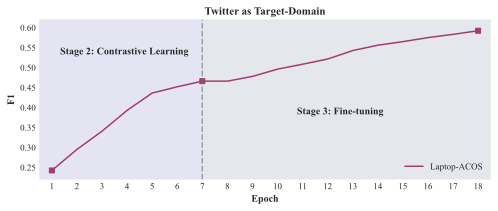

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 设置matplotlib样式
plt.style.use('seaborn-v0_8-darkgrid')  # 使用seaborn风格
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['font.family'] = 'Times New Roman'  # 设置字体为Times New Roman


%config InlineBackend.figure_format = 'svg'


# ============ 数据准备 ============
# 阶段epoch数
stage1_epochs = 7
stage2_epochs = 11



# 数据（F1）
stage1_f1 = [0.2425, 0.2951, 0.3407, 0.3928, 0.4362, 0.4519, 0.4660]
stage2_f1 = [0.4660, 0.4779, 0.4961, 0.5084, 0.5214, 0.5426, 0.5560, 0.5649, 0.5750, 0.5831, 0.5922]

stage1_f12 = [0.1496, 0.2714, 0.3603, 0.4081, 0.4241, 0.4765, 0.4705, 0.4872, 0.5068, 0.5203, 0.5128, 0.5021, 0.5214]
stage2_f12 = [0.5214,0.5340, 0.5631, 0.5469, 0.5566, 0.5631, 0.5728, 0.5922]

# 横坐标
stage1_x = np.arange(1, stage1_epochs + 1)
stage2_x = np.arange(stage1_epochs + 1, stage1_epochs + stage2_epochs + 1)

# 拼接连续坐标和数据
x_all = np.concatenate([stage1_x, stage2_x])
f1_all = np.concatenate([stage1_f1, stage2_f1])


# ============ 绘图 ============
fig, ax = plt.subplots(figsize=(7, 3))  # 缩小尺寸

color_f1 = '#A23B72'  # 紫红色系 - F1

# 连续绘制F1曲线，无标记
ax.plot(x_all, f1_all, color=color_f1, linewidth=1.5, label='Laptop-ACOS')

# ============ 添加关键点标记 ============
# 1. 第一阶段起始点（epoch 1）
ax.plot(1, stage1_f1[0], marker='s', markersize=5, color='#A23B72')

# 2. 两个阶段连接点（epoch 13）
ax.plot(stage1_epochs, stage1_f1[-1], marker='s', markersize=5, color='#A23B72', )

# 3. 第二阶段结束点（epoch 18）
ax.plot(stage1_epochs + stage2_epochs, stage2_f1[-1], marker='s', markersize=5, color='#A23B72')


# 阶段分割线和背景色
ax.axvline(x=stage1_epochs, color='#6C757D', linestyle='--', linewidth=1.5, alpha=0.6)
ax.axvspan(0.5, stage1_epochs, alpha=0.03, color='blue')
ax.axvspan(stage1_epochs, stage1_epochs + stage2_epochs + 0.5, alpha=0.03, color='green')

# 阶段标注
# ax.text(stage1_epochs / 1.8, 0.25, 'Stage 2: Contrastive Learning', 
#         ha='center', va='top', fontsize=9, fontweight='bold', 
#         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
# ax.text(stage1_epochs + stage2_epochs / 2, 0.25, 'Stage 3: Fine-tuning', 
#         ha='center', va='top', fontsize=9, fontweight='bold',
#         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))


ax.text(stage1_epochs / 1.8, 0.55, 'Stage 2: Contrastive Learning', 
        ha='center', va='top', fontsize=10, fontweight='bold')
ax.text(stage1_epochs + stage2_epochs / 2, 0.4, 'Stage 3: Fine-tuning', 
        ha='center', va='top', fontsize=10, fontweight='bold')

# 坐标轴设置
ax.set_xlabel('Epoch', fontsize=10, fontweight='bold')
ax.set_ylabel('F1', fontsize=10, fontweight='bold')
ax.set_ylim(0.22, 0.62)
ax.set_xlim(0.5, stage1_epochs + stage2_epochs + 0.5)

# x轴刻度
xticks = list(range(1, stage1_epochs + stage2_epochs + 1))
xtick_labels = [str(i) for i in xticks]
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)

ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.7)
ax.legend(loc='lower right', fontsize=9, framealpha=0.95, shadow=True)

# 标题
ax.set_title('Twitter as Target-Domain', 
             fontsize=11, fontweight='bold', pad=5)

plt.tight_layout()

plt.savefig('twitter.svg', dpi=300, bbox_inches='tight')
plt.savefig('twitter.pdf', bbox_inches='tight', format='pdf')

print("图片已保存为: twitter.svg 和 twitter.pdf")

plt.show()


图片已保存为: twitter2.svg 和 twitter2.pdf


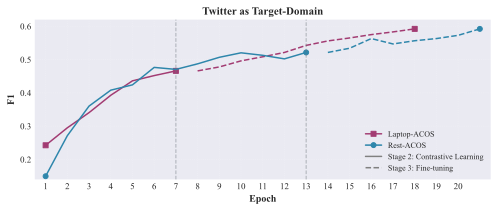

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 设置matplotlib样式
plt.style.use('seaborn-v0_8-darkgrid')  # 使用seaborn风格
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['font.family'] = 'Times New Roman'  # 设置字体为Times New Roman

%config InlineBackend.figure_format = 'svg'

# ============ 数据准备 ============
# 阶段epoch数
stage1_epochs = 7
stage2_epochs = 11

# 数据（F1），第一组曲线
stage1_f1 = [0.2425, 0.2951, 0.3407, 0.3928, 0.4362, 0.4519, 0.4660]
stage2_f1 = [0.4660, 0.4779, 0.4961, 0.5084, 0.5214, 0.5426, 0.5560, 0.5649, 0.5750, 0.5831, 0.5922]

# 第二组曲线
stage1_f12 = [0.1496, 0.2714, 0.3603, 0.4081, 0.4241, 0.4765, 0.4705, 0.4872, 0.5068, 0.5203, 0.5128, 0.5021, 0.5214]
stage2_f12 = [0.5214, 0.5340, 0.5631, 0.5469, 0.5566, 0.5631, 0.5728, 0.5922]

# 横坐标 - 第一组
stage1_x_1 = np.arange(1, stage1_epochs + 1)
stage2_x_1 = np.arange(stage1_epochs + 1, stage1_epochs + stage2_epochs + 1)

# 拼接完整数据 - 第一组
x_all_1 = np.concatenate([stage1_x_1, stage2_x_1])
f1_all_1 = np.concatenate([stage1_f1, stage2_f1])

# 第二组数据长度
stage1_epochs_2 = len(stage1_f12)
stage2_epochs_2 = len(stage2_f12)
stage1_x_2 = np.arange(1, stage1_epochs_2 + 1)
stage2_x_2 = np.arange(stage1_epochs_2 + 1, stage1_epochs_2 + stage2_epochs_2 + 1)

# 拼接完整数据 - 第二组
x_all_2 = np.concatenate([stage1_x_2, stage2_x_2])
f1_all_2 = np.concatenate([stage1_f12, stage2_f12])

# ============ 绘图 ============
fig, ax = plt.subplots(figsize=(7, 3))  # 缩小尺寸

# 第一组曲线颜色
color_1 = '#A23B72'  # 紫红色
# 第二组曲线颜色
color_2 = '#2E86AB'  # 蓝色

# ============ 绘制第一组曲线（Laptop-ACOS）- 分段不同线型 ============
# Stage 2部分: 实线
ax.plot(stage1_x_1, stage1_f1, color=color_1, linewidth=1.5, linestyle='-')

# Stage 3部分: 虚线
ax.plot(stage2_x_1, stage2_f1, color=color_1, linewidth=1.5, linestyle='--')

# 关键点标记 - 第一组
ax.plot(1, stage1_f1[0], marker='s', markersize=5, color=color_1)
ax.plot(stage1_epochs, stage1_f1[-1], marker='s', markersize=5, color=color_1)
ax.plot(stage1_epochs + stage2_epochs, stage2_f1[-1], marker='s', markersize=5, color=color_1)

# ============ 绘制第二组曲线（Rest-ACOS）- 分段不同线型 ============
# Stage 2部分: 实线
ax.plot(stage1_x_2, stage1_f12, color=color_2, linewidth=1.5, linestyle='-')

# Stage 3部分: 虚线
ax.plot(stage2_x_2, stage2_f12, color=color_2, linewidth=1.5, linestyle='--')

# 关键点标记 - 第二组
ax.plot(1, stage1_f12[0], marker='o', markersize=5, color=color_2)
ax.plot(stage1_epochs_2, stage1_f12[-1], marker='o', markersize=5, color=color_2)
ax.plot(stage1_epochs_2 + stage2_epochs_2, stage2_f12[-1], marker='o', markersize=5, color=color_2)

# 阶段分割线
ax.axvline(x=stage1_epochs, color='#6C757D', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=stage1_epochs_2, color='#6C757D', linestyle='--', linewidth=1, alpha=0.5)

# 坐标轴设置
ax.set_xlabel('Epoch', fontsize=10, fontweight='bold')
ax.set_ylabel('F1', fontsize=10, fontweight='bold')
ax.set_ylim(0.14, 0.62)
ax.set_xlim(0.5, max(stage1_epochs + stage2_epochs, stage1_epochs_2 + stage2_epochs_2) + 0.5)

# x轴刻度
xticks = list(range(1, int(ax.get_xlim()[1])))
xtick_labels = [str(i) for i in xticks]
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)

ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.7)

# ============ 自定义图例 ============
from matplotlib.lines import Line2D

# 创建自定义图例元素
legend_elements = [
    Line2D([0], [0], color=color_1, linewidth=1.5, linestyle='-', marker='s', 
           markersize=5, label='Laptop-ACOS'),
    Line2D([0], [0], color=color_2, linewidth=1.5, linestyle='-', marker='o', 
           markersize=5, label='Rest-ACOS'),
    Line2D([0], [0], color='gray', linewidth=1.5, linestyle='-', label='Stage 2: Contrastive Learning'),
    Line2D([0], [0], color='gray', linewidth=1.5, linestyle='--', label='Stage 3: Fine-tuning'),
]

ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.95, shadow=True, ncol=1)

# 标题
ax.set_title('Twitter as Target-Domain', 
             fontsize=11, fontweight='bold', pad=5)

plt.tight_layout()

# plt.savefig('twitter2.svg', dpi=300, bbox_inches='tight')
# plt.savefig('twitter2.pdf', bbox_inches='tight', format='pdf')

# print("图片已保存为: twitter2.svg 和 twitter2.pdf")

plt.show()


图片已保存为: twitter.svg 和 twitter.pdf


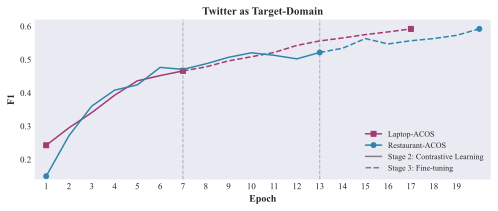

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 设置matplotlib样式
plt.style.use('seaborn-v0_8-darkgrid')  # 使用seaborn风格
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['font.family'] = 'Times New Roman'  # 设置字体为Times New Roman

%config InlineBackend.figure_format = 'svg'

# ============ 数据准备 ============
# 阶段epoch数
stage1_epochs = 7
stage2_epochs = 11

# 数据（F1），第一组曲线
stage1_f1 = [0.2425, 0.2951, 0.3407, 0.3928, 0.4362, 0.4519, 0.4660]
stage2_f1 = [0.4660, 0.4779, 0.4961, 0.5084, 0.5214, 0.5426, 0.5560, 0.5649, 0.5750, 0.5831, 0.5922]

# 第二组曲线
stage1_f12 = [0.1496, 0.2714, 0.3603, 0.4081, 0.4241, 0.4765, 0.4705, 0.4872, 0.5068, 0.5203, 0.5128, 0.5021, 0.5214]
stage2_f12 = [0.5214, 0.5340, 0.5631, 0.5469, 0.5566, 0.5631, 0.5728, 0.5922]

# 横坐标 - 第一组
# stage1: epoch 1-7 (7个点)
# stage2: epoch 7-18 (11个点，包含起点7)
stage1_x_1 = np.arange(1, stage1_epochs + 1)  # [1,2,3,4,5,6,7]
stage2_x_1 = np.arange(stage1_epochs, stage1_epochs + stage2_epochs)  # [7,8,9,...,17,18] 共11个

# 第二组数据长度
stage1_epochs_2 = len(stage1_f12)  # 13
stage2_epochs_2 = len(stage2_f12)  # 8

# stage1: epoch 1-13 (13个点)
# stage2: epoch 13-20 (8个点，包含起点13)
stage1_x_2 = np.arange(1, stage1_epochs_2 + 1)  # [1,2,...,13]
stage2_x_2 = np.arange(stage1_epochs_2, stage1_epochs_2 + stage2_epochs_2)  # [13,14,...,20] 共8个

# ============ 绘图 ============
fig, ax = plt.subplots(figsize=(7, 3))  # 缩小尺寸

# 第一组曲线颜色
color_1 = '#A23B72'  # 紫红色
# 第二组曲线颜色
color_2 = '#2E86AB'  # 蓝色

# ============ 绘制第一组曲线（Laptop-ACOS）- 分段不同线型 ============
# Stage 2部分: 实线
line1_stage2, = ax.plot(stage1_x_1, stage1_f1, color=color_1, linewidth=1.5, linestyle='-')

# Stage 3部分: 虚线（从epoch 7开始，包含连接点）
line1_stage3, = ax.plot(stage2_x_1, stage2_f1, color=color_1, linewidth=1.5, linestyle='--')

# 关键点标记 - 第一组
ax.plot(1, stage1_f1[0], marker='s', markersize=5, color=color_1)
ax.plot(stage1_epochs, stage1_f1[-1], marker='s', markersize=5, color=color_1)
ax.plot(stage2_x_1[-1], stage2_f1[-1], marker='s', markersize=5, color=color_1)

# ============ 绘制第二组曲线（Rest-ACOS）- 分段不同线型 ============
# Stage 2部分: 实线
line2_stage2, = ax.plot(stage1_x_2, stage1_f12, color=color_2, linewidth=1.5, linestyle='-')

# Stage 3部分: 虚线（从epoch 13开始，包含连接点）
line2_stage3, = ax.plot(stage2_x_2, stage2_f12, color=color_2, linewidth=1.5, linestyle='--')

# 关键点标记 - 第二组
ax.plot(1, stage1_f12[0], marker='o', markersize=5, color=color_2)
ax.plot(stage1_epochs_2, stage1_f12[-1], marker='o', markersize=5, color=color_2)
ax.plot(stage2_x_2[-1], stage2_f12[-1], marker='o', markersize=5, color=color_2)

# 阶段分割线
ax.axvline(x=stage1_epochs, color='#6C757D', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=stage1_epochs_2, color='#6C757D', linestyle='--', linewidth=1, alpha=0.5)

# 坐标轴设置
ax.set_xlabel('Epoch', fontsize=10, fontweight='bold')
ax.set_ylabel('F1', fontsize=10, fontweight='bold')
ax.set_ylim(0.14, 0.62)
ax.set_xlim(0.5, max(stage2_x_1[-1], stage2_x_2[-1]) + 0.5)

# x轴刻度
xticks = list(range(1, int(ax.get_xlim()[1])))
xtick_labels = [str(i) for i in xticks]
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)

ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.7)

# ============ 自定义图例 ============
from matplotlib.lines import Line2D

# 创建自定义图例元素
legend_elements = [
    Line2D([0], [0], color=color_1, linewidth=1.5, linestyle='-', marker='s', 
           markersize=5, label='Laptop-ACOS'),
    Line2D([0], [0], color=color_2, linewidth=1.5, linestyle='-', marker='o', 
           markersize=5, label='Restaurant-ACOS'),
    Line2D([0], [0], color='gray', linewidth=1.5, linestyle='-', label='Stage 2: Contrastive Learning'),
    Line2D([0], [0], color='gray', linewidth=1.5, linestyle='--', label='Stage 3: Fine-tuning'),
]

ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.95, shadow=True, ncol=1)

# 标题
ax.set_title('Twitter as Target-Domain', 
             fontsize=11, fontweight='bold', pad=5)

plt.tight_layout()

plt.savefig('twitter.svg', dpi=300, bbox_inches='tight')
plt.savefig('twitter.pdf', bbox_inches='tight', format='pdf')

print("图片已保存为: twitter.svg 和 twitter.pdf")

plt.show()


图片已保存为: reddit.svg 和 reddit.pdf


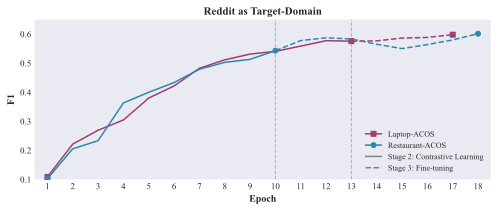

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 设置matplotlib样式
plt.style.use('seaborn-v0_8-darkgrid')  # 使用seaborn风格
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['font.family'] = 'Times New Roman'  # 设置字体为Times New Roman

%config InlineBackend.figure_format = 'svg'

# ============ 数据准备 ============
# 第一组数据
stage1_epochs = 13
stage2_epochs = 5

stage1_f1 = [0.1088, 0.2216, 0.2693, 0.3047, 0.3801, 0.4218, 0.4826, 0.5117, 0.5314, 0.5409, 0.5590, 0.5775, 0.5759]
stage2_f1 = [0.5759, 0.5769, 0.5865, 0.5887, 0.5983]

# 第二组数据
stage1_f12 = [0.1025, 0.2055, 0.2334, 0.3633, 0.4001, 0.4335, 0.4794, 0.5029, 0.5133, 0.5432]
stage2_f12 = [0.5432, 0.5778, 0.5876, 0.5833, 0.5652, 0.5502, 0.5641, 0.5801, 0.6015]

# 第一组横坐标
# stage1: epoch 1-13 (13个点)
# stage2: epoch 13-17 (5个点，包含起点13)
stage1_x_1 = np.arange(1, stage1_epochs + 1)  # [1,2,...,13] 共13个
stage2_x_1 = np.arange(stage1_epochs, stage1_epochs + stage2_epochs)  # [13,14,15,16,17] 共5个

# 第二组横坐标
stage1_epochs_2 = len(stage1_f12)  # 10
stage2_epochs_2 = len(stage2_f12)  # 9

# stage1: epoch 1-10 (10个点)
# stage2: epoch 10-18 (9个点，包含起点10)
stage1_x_2 = np.arange(1, stage1_epochs_2 + 1)  # [1,2,...,10] 共10个
stage2_x_2 = np.arange(stage1_epochs_2, stage1_epochs_2 + stage2_epochs_2)  # [10,11,...,18] 共9个

# ============ 绘图 ============
fig, ax = plt.subplots(figsize=(7, 3))

# 颜色设置
color_1 = '#A23B72'  # 紫红色 - 第一组
color_2 = '#2E86AB'  # 蓝色 - 第二组

# ============ 绘制第一组曲线（Laptop-ACOS）============
# Stage 2: 实线
ax.plot(stage1_x_1, stage1_f1, color=color_1, linewidth=1.5, linestyle='-')

# Stage 3: 虚线
ax.plot(stage2_x_1, stage2_f1, color=color_1, linewidth=1.5, linestyle='--')

# 关键点标记 - 第一组
ax.plot(1, stage1_f1[0], marker='s', markersize=5, color=color_1)
ax.plot(stage1_epochs, stage1_f1[-1], marker='s', markersize=5, color=color_1)
ax.plot(stage2_x_1[-1], stage2_f1[-1], marker='s', markersize=5, color=color_1)

# ============ 绘制第二组曲线（Rest-ACOS）============
# Stage 2: 实线
ax.plot(stage1_x_2, stage1_f12, color=color_2, linewidth=1.5, linestyle='-')

# Stage 3: 虚线
ax.plot(stage2_x_2, stage2_f12, color=color_2, linewidth=1.5, linestyle='--')

# 关键点标记 - 第二组
ax.plot(1, stage1_f12[0], marker='o', markersize=5, color=color_2)
ax.plot(stage1_epochs_2, stage1_f12[-1], marker='o', markersize=5, color=color_2)
ax.plot(stage2_x_2[-1], stage2_f12[-1], marker='o', markersize=5, color=color_2)

# 阶段分割线
ax.axvline(x=stage1_epochs, color='#6C757D', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=stage1_epochs_2, color='#6C757D', linestyle='--', linewidth=1, alpha=0.5)

# 坐标轴设置
ax.set_xlabel('Epoch', fontsize=10, fontweight='bold')
ax.set_ylabel('F1', fontsize=10, fontweight='bold')
ax.set_ylim(0.1, 0.65)
ax.set_xlim(0.5, max(stage2_x_1[-1], stage2_x_2[-1]) + 0.5)

# x轴刻度
xticks = list(range(1, int(ax.get_xlim()[1]) + 1))
xtick_labels = [str(i) for i in xticks]
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)

ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.7)

# ============ 自定义图例 ============
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color=color_1, linewidth=1.5, linestyle='-', marker='s', 
           markersize=5, label='Laptop-ACOS'),
    Line2D([0], [0], color=color_2, linewidth=1.5, linestyle='-', marker='o', 
           markersize=5, label='Restaurant-ACOS'),
    Line2D([0], [0], color='gray', linewidth=1.5, linestyle='-', label='Stage 2: Contrastive Learning'),
    Line2D([0], [0], color='gray', linewidth=1.5, linestyle='--', label='Stage 3: Fine-tuning'),
]

ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.95, shadow=True, ncol=1)

# 标题
ax.set_title('Reddit as Target-Domain', 
             fontsize=11, fontweight='bold', pad=5)

plt.tight_layout()

plt.savefig('reddit.svg', dpi=300, bbox_inches='tight')
plt.savefig('reddit.pdf', bbox_inches='tight', format='pdf')

print("图片已保存为: reddit.svg 和 reddit.pdf")

plt.show()


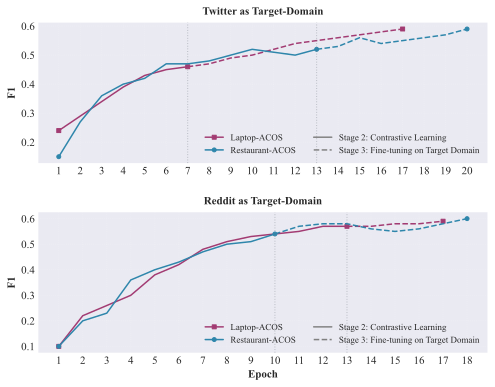

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ============ 全局样式设置 ============
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.unicode_minus'] = False
%config InlineBackend.figure_format = 'svg'

# 颜色配置
color_1 = '#A23B72'  # 紫红色 (Laptop-ACOS)
color_2 = '#2E86AB'  # 蓝色 (Restaurant-ACOS)

def plot_subsegment(ax, s1_data1, s2_data1, s1_data2, s2_data2, title, is_last=False):
    # 横坐标计算
    x1_s1 = np.arange(1, len(s1_data1) + 1)
    x1_s2 = np.arange(len(s1_data1), len(s1_data1) + len(s2_data1))
    x2_s1 = np.arange(1, len(s1_data2) + 1)
    x2_s2 = np.arange(len(s1_data2), len(s1_data2) + len(s2_data2))
    
    # 绘制第一组曲线 (Laptop)
    ax.plot(x1_s1, s1_data1, color=color_1, linewidth=1.5, linestyle='-')
    ax.plot(x1_s2, s2_data1, color=color_1, linewidth=1.5, linestyle='--')
    ax.plot([1, x1_s1[-1], x1_s2[-1]], [s1_data1[0], s1_data1[-1], s2_data1[-1]], 's', markersize=4, color=color_1)
    
    # 绘制第二组曲线 (Rest)
    ax.plot(x2_s1, s1_data2, color=color_2, linewidth=1.5, linestyle='-')
    ax.plot(x2_s2, s2_data2, color=color_2, linewidth=1.5, linestyle='--')
    ax.plot([1, x2_s1[-1], x2_s2[-1]], [s1_data2[0], s1_data2[-1], s2_data2[-1]], 'o', markersize=4, color=color_2)
    
    # 阶段分割线
    ax.axvline(x=len(s1_data1), color='#6C757D', linestyle=':', linewidth=1, alpha=0.4)
    ax.axvline(x=len(s1_data2), color='#6C757D', linestyle=':', linewidth=1, alpha=0.4)
    
    # 细节美化
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_ylabel('F1', fontweight='bold')
    if is_last:
        ax.set_xlabel('Epoch', fontweight='bold')
    
    # 设置图例 (每个图都有)
    legend_elements = [
        Line2D([0], [0], color=color_1, linestyle='-', marker='s', markersize=4, label='Laptop-ACOS'),
        Line2D([0], [0], color=color_2, linestyle='-', marker='o', markersize=4, label='Restaurant-ACOS'),
        Line2D([0], [0], color='gray', linestyle='-', label='Stage 2: Contrastive Learning'),
        Line2D([0], [0], color='gray', linestyle='--', label='Stage 3: Fine-tuning on Target Domain'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.8, ncol=2)
    
    # 刻度控制
    ax.grid(True, alpha=0.2, linestyle=':')
    max_x = max(x1_s2[-1], x2_s2[-1])
    ax.set_xticks(range(1, max_x + 1))

# ============ 数据准备 ============
# Twitter
t_s1_f1, t_s2_f1 = [0.24, 0.29, 0.34, 0.39, 0.43, 0.45, 0.46], [0.46, 0.47, 0.49, 0.50, 0.52, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59]
t_s1_f12, t_s2_f12 = [0.15, 0.27, 0.36, 0.40, 0.42, 0.47, 0.47, 0.48, 0.50, 0.52, 0.51, 0.50, 0.52], [0.52, 0.53, 0.56, 0.54, 0.55, 0.56, 0.57, 0.59]
# Reddit
r_s1_f1, r_s2_f1 = [0.10, 0.22, 0.26, 0.30, 0.38, 0.42, 0.48, 0.51, 0.53, 0.54, 0.55, 0.57, 0.57], [0.57, 0.57, 0.58, 0.58, 0.59]
r_s1_f12, r_s2_f12 = [0.10, 0.20, 0.23, 0.36, 0.40, 0.43, 0.47, 0.50, 0.51, 0.54], [0.54, 0.57, 0.58, 0.58, 0.56, 0.55, 0.56, 0.58, 0.60]

# ============ 绘图 ============
# figsize 的第二个参数从 7 改为 5.5，压缩高度
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5.5))

plot_subsegment(ax1, t_s1_f1, t_s2_f1, t_s1_f12, t_s2_f12, 'Twitter as Target-Domain')
plot_subsegment(ax2, r_s1_f1, r_s2_f1, r_s1_f12, r_s2_f12, 'Reddit as Target-Domain', is_last=True)

plt.tight_layout()
# 增加子图间的间距，避免标题和坐标轴重叠
plt.subplots_adjust(hspace=0.35) 

plt.savefig('compressed_analysis.pdf', bbox_inches='tight')
plt.savefig('compressed_analysis.svg', dpi=300, bbox_inches='tight')
plt.show()

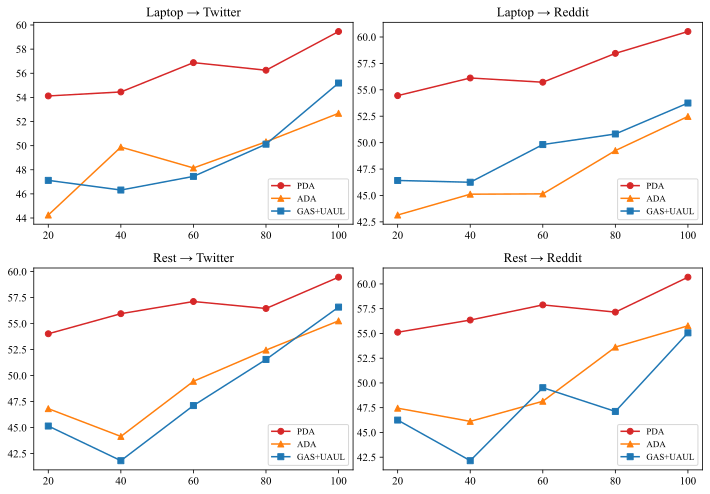

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 设置样式和字体
# plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Times New Roman' # 建议保留，使论文图表更专业
%config InlineBackend.figure_format = 'svg'

plt.rcParams['figure.figsize'] = (10, 7) 

# 原始数据
ratios = np.array([20, 40, 60, 80, 100])

# 任务数据定义 (F1 * 100)
tasks = {
    'Laptop → Twitter': {
        'PDA': [54.12, 54.45, 56.88, 56.25, 59.46],
        'ADA':  [44.25, 49.88, 48.15, 50.32, 52.68],
        'GAS+UAUL':  [47.12, 46.32, 47.45, 50.12, 55.19]
    },
    'Laptop → Reddit': {
        'PDA': [54.45, 56.12, 55.72, 58.45, 60.52],
        'ADA':  [43.15, 45.12, 45.15, 49.25, 52.48],
        'GAS+UAUL':  [46.42, 46.25, 49.82, 50.82, 53.75]
    },
    'Rest → Twitter': {
        'PDA': [54.02, 55.95, 57.12, 56.45, 59.46],
        'ADA':  [46.82, 44.15, 49.45, 52.45, 55.26],
        'GAS+UAUL':  [45.15, 41.82, 47.12, 51.55, 56.58]
    },
    'Rest → Reddit': {
        'PDA': [55.12, 56.35, 57.88, 57.15, 60.68],
        'ADA':  [47.45, 46.12, 48.15, 53.62, 55.77],
        'GAS+UAUL':  [46.25, 42.15, 49.52, 47.12, 55.06]
    }
}

fig, axes = plt.subplots(2, 2)
axes = axes.flatten()

# 颜色和标记配置
colors = {'PDA': '#D62728', 'GAS+UAUL': '#1F77B4', 'ADA': '#FF7F0E'}
markers = {'PDA': 'o', 'GAS+UAUL': 's', 'ADA': '^'}

for i, (task_name, models) in enumerate(tasks.items()):
    ax = axes[i]
    
    # 直接绘制折线
    for model_name, y_values in models.items():
        y_values = np.array(y_values)
        
        # 使用原始 ratios 绘图，消除插值平滑
        ax.plot(ratios, y_values, label=model_name, color=colors[model_name], 
                marker=markers[model_name], linewidth=1.5, markersize=6)
    
    ax.set_title(task_name)
    # ax.set_xlabel('Target Data Ratio (%)')
    # ax.set_ylabel('F1 Score (%)')
    ax.set_xticks(ratios)
    ax.legend(loc='lower right',fontsize=9)

plt.tight_layout()
# 增加子图间的间距，避免标题和坐标轴重叠
# plt.subplots_adjust(hspace=0.1) 
# plt.subplots_adjust(vspace=0.1) 
plt.savefig('samples.pdf', bbox_inches='tight')
plt.savefig('samples.svg', dpi=300, bbox_inches='tight')
plt.show()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

def function(df_live):
    

    df = df_live.copy()
    df['StartTime'] = pd.to_datetime(df['StartTime'])
    df['EndTime'] = pd.to_datetime(df['EndTime'])

    maxlimit = 1.0
    comp_effects = []   ##存放目标直播间的comp_effect值

    # 找出Status在[30, 50] 的直播间
    mask_probe = (df['Status'] >= 30) & (df['Status'] <= 50)
    probes = df[mask_probe].copy()

    ## 获取每一条当前的直播间
    for idx, row in probes.iterrows():
        category = row['Category']
        s_time = row['StartTime']

        # 寻找同类的并且状态在[30,60)，同时在该直播间开播前5分钟处于在线状态的其他直播间

        # 
        mask_other = (
            (df['StreamID'] != row['StreamID']) &
            (df['Category'] == category) &
            (df['Status'] >= 30) & (df['Status'] < 60) &

            ## 当前时间和前5分钟均要在其他对手直播阶段中
            (df['StartTime'] <= s_time) & (df['EndTime'] >= s_time - pd.Timedelta(minutes=5))
        )
        ## 得到当前
        competitors = df[mask_other]

        # 计算修正后的系数
        adjfactors = competitors['AdjFactor'].copy()
        adjfactors = adjfactors.fillna(0)  
        adjfactors = adjfactors.clip(upper=maxlimit)

        comp = (competitors['HeatScore'] * adjfactors).sum()
        comp_effects.append((idx, comp))

    # 将每一个直播间计算的对手直播间的comp_effect，写入原来的df_live
    df_live['CompEffect'] = np.nan
    for idx, comp in comp_effects:
        df_live.at[idx, 'CompEffect'] = comp

    return df_live


    
